# Task 2 — Frustration classification from HR features

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedGroupKFold, cross_validate, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (make_scorer, f1_score, classification_report, ConfusionMatrixDisplay)

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler

from scipy.stats import wilcoxon

In [2]:
df = pd.read_csv("HR_data.csv")
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

display(df.head())
print(df.shape)
print(df.columns.tolist())

,HR_Mean,HR_Median,HR_std,HR_Min,HR_Max,HR_AUC,Round,Phase,Individual,Puzzler,Frustrated,Cohort
0,77.965186,78.00,3.345290,73.23,83.37,22924.945,round_3,phase3,1,1,1,D1_1
1,70.981097,70.57,2.517879,67.12,78.22,21930.400,round_3,phase2,1,1,5,D1_1
2,73.371959,73.36,3.259569,67.88,80.22,21647.085,round_3,phase1,1,1,0,D1_1
3,78.916822,77.88,4.054595,72.32,84.92,25258.905,round_2,phase3,1,1,1,D1_1
4,77.322226,74.55,6.047603,70.52,90.15,23890.565,round_2,phase2,1,1,5,D1_1


(168, 12)
['HR_Mean', 'HR_Median', 'HR_std', 'HR_Min', 'HR_Max', 'HR_AUC', 'Round', 'Phase', 'Individual', 'Puzzler', 'Frustrated', 'Cohort']


In [3]:
features = ["HR_Mean", "HR_Median", "HR_std", "HR_Min", "HR_Max", "HR_AUC"]

X = df[features]
y = df["Frustrated"]
groups = df["Individual"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (168, 6)
y shape: (168,)


In [ ]:
RANDOM_STATE = 67
cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

for fold, (_, test_idx) in enumerate(cv.split(X, y, groups), start=1):
    test_individuals = groups.iloc[test_idx].unique()
    print(f"Fold {fold}")
    print("  Test rows:", len(test_idx))
    print("  Test individuals:", test_individuals)
    print("  Test class counts:")
    print(y.iloc[test_idx].value_counts().sort_index().to_string())
    print()

Fold 1
  Test rows: 36
  Test individuals: [ 6 13 14]
  Test class counts:
Frustrated
0     6
1    14
2     4
3     1
4     3
5     4
6     2
7     1
8     1

Fold 2
  Test rows: 36
  Test individuals: [ 5  8 10]
  Test class counts:
Frustrated
0    8
1    8
2    8
3    4
4    5
5    3

Fold 3
  Test rows: 24
  Test individuals: [ 7 12]
  Test class counts:
Frustrated
0    3
1    6
2    3
3    4
4    3
5    2
6    2
8    1

Fold 4
  Test rows: 36
  Test individuals: [ 1  4 11]
  Test class counts:
Frustrated
0    8
1    8
2    9
3    3
4    5
5    2
7    1

Fold 5
  Test rows: 36
  Test individuals: [2 3 9]
  Test class counts:
Frustrated
0    4
1    9
2    7
3    4
4    7
5    3
6    1
8    1



c:\Users\dalga\miniforge3\envs\ml\Lib\site-packages\sklearn\model_selection\_split.py:1037: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


## Defining le models

In [ ]:
models = {

    "Random Forest": Pipeline([
        ("model", RandomForestClassifier(
            n_estimators=500,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),

    "ANN": Pipeline([
        ("scaler", StandardScaler()),
        ("sampler", RandomOverSampler(random_state=RANDOM_STATE)),
        ("model", MLPClassifier(
            hidden_layer_sizes=(16,),
            alpha=0.01,
            solver="lbfgs",
            max_iter=5000,
            random_state=RANDOM_STATE
        ))
    ])
}

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "macro_f1": make_scorer(f1_score, average="macro", zero_division=0)
}

## Cross-validated model comparison :O

In [6]:
summary_rows = []
fold_scores = {}

for model_name, model in models.items():
    scores = cross_validate(
        model,
        X,
        y,
        groups=groups,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        error_score="raise"
    )

    fold_scores[model_name] = scores

    for metric_name in scoring:
        values = scores[f"test_{metric_name}"]
        summary_rows.append({
            "model": model_name,
            "metric": metric_name,
            "mean": values.mean(),
            "std": values.std(ddof=1),
            "fold_scores": np.round(values, 3)
        })

results = pd.DataFrame(summary_rows)
display(results)

c:\Users\dalga\miniforge3\envs\ml\Lib\site-packages\sklearn\model_selection\_split.py:1037: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\dalga\miniforge3\envs\ml\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\dalga\miniforge3\envs\ml\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\dalga\miniforge3\envs\ml\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\dalga\miniforge3\envs\ml\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y

,model,metric,mean,std,fold_scores
0,Random Forest,accuracy,0.102778,0.043479,"[0.056, 0.167, 0.125, 0.083, 0.083]"
1,Random Forest,balanced_accuracy,0.083823,0.040780,"[0.026, 0.125, 0.115, 0.094, 0.059]"
2,Random Forest,macro_f1,0.074742,0.032847,"[0.036, 0.084, 0.109, 0.1, 0.045]"
3,ANN,accuracy,0.144444,0.063343,"[0.25, 0.111, 0.083, 0.139, 0.139]"
4,ANN,balanced_accuracy,0.109689,0.057070,"[0.192, 0.083, 0.042, 0.137, 0.095]"
5,ANN,macro_f1,0.092921,0.057025,"[0.185, 0.064, 0.031, 0.092, 0.093]"


## statistical comparison, only 5 folds so the statistical power is low

In [7]:
metric = "macro_f1"

rf = fold_scores["Random Forest"][f"test_{metric}"]
ann = fold_scores["ANN"][f"test_{metric}"]

print("Random Forest fold scores:", np.round(rf, 3))
print("ANN fold scores:", np.round(ann, 3))
print("Differences RF - ANN:", np.round(rf - ann, 3))

stat, p_value = wilcoxon(rf, ann)
print(f"Wilcoxon signed-rank test for {metric}: statistic={stat:.3f}, p={p_value:.3f}")

Random Forest fold scores: [0.036 0.084 0.109 0.1   0.045]
ANN fold scores: [0.185 0.064 0.031 0.092 0.093]
Differences RF - ANN: [-0.149  0.019  0.078  0.008 -0.048]
Wilcoxon signed-rank test for macro_f1: statistic=7.000, p=1.000


## Confusion matrices and classification reports

Made to show which frustration classes the models "have a problem"? with

c:\Users\dalga\miniforge3\envs\ml\Lib\site-packages\sklearn\model_selection\_split.py:1037: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(



Random Forest
              precision    recall  f1-score   support

           0       0.23      0.24      0.23        29
           1       0.11      0.09      0.10        45
           2       0.08      0.06      0.07        31
           3       0.19      0.19      0.19        16
           4       0.06      0.04      0.05        23
           5       0.00      0.00      0.00        14
           6       0.00      0.00      0.00         5
           7       0.00      0.00      0.00         2
           8       0.00      0.00      0.00         3

    accuracy                           0.10       168
   macro avg       0.07      0.07      0.07       168
weighted avg       0.11      0.10      0.10       168



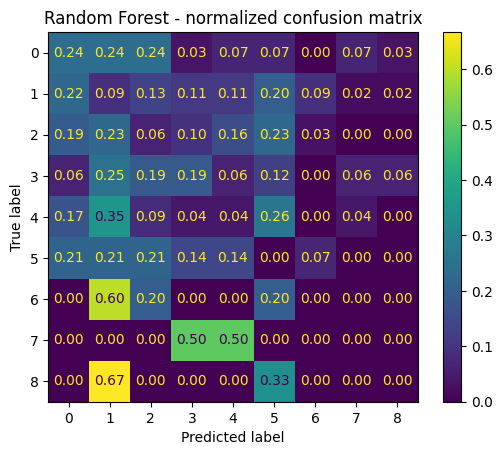


ANN


c:\Users\dalga\miniforge3\envs\ml\Lib\site-packages\sklearn\model_selection\_split.py:1037: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\dalga\miniforge3\envs\ml\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\Users\dalga\miniforge3\envs\ml\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_i

              precision    recall  f1-score   support

           0       0.29      0.21      0.24        29
           1       0.21      0.20      0.21        45
           2       0.11      0.13      0.12        31
           3       0.00      0.00      0.00        16
           4       0.17      0.09      0.11        23
           5       0.14      0.29      0.19        14
           6       0.00      0.00      0.00         5
           7       0.00      0.00      0.00         2
           8       0.00      0.00      0.00         3

    accuracy                           0.15       168
   macro avg       0.10      0.10      0.10       168
weighted avg       0.16      0.15      0.15       168



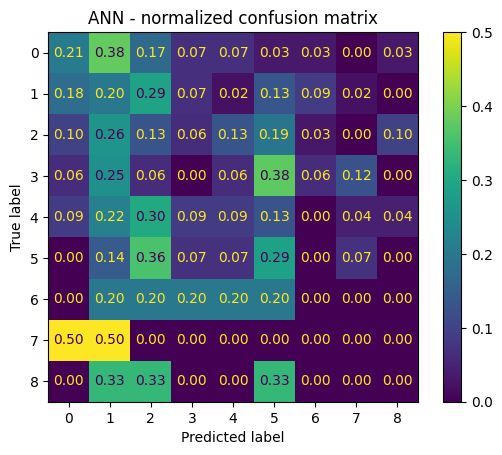

In [8]:
for model_name in ["Random Forest", "ANN"]:
    print("\n" + "=" * 80)
    print(model_name)

    y_pred = cross_val_predict(
        models[model_name],
        X,
        y,
        groups=groups,
        cv=cv
    )

    print(classification_report(y, y_pred, zero_division=0))

    ConfusionMatrixDisplay.from_predictions(
        y,
        y_pred,
        normalize="true",
        values_format=".2f"
    )
    plt.title(f"{model_name} - normalized confusion matrix")
    plt.show()